In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use('ggplot')

In [3]:
df = pd.DataFrame({
    "group": list(range(1, 17)),
    "female": [18, 31, 34, 33, 27, 33, 28, 23, 33, 12, 19, 25, 14, 4, 22, 7],
    "male":   [11, 22, 27, 29, 24, 29, 25, 26, 38, 14, 23, 31, 20, 6, 34, 12]
})

In [4]:
df

,group,female,male
0,1,18,11
1,2,31,22
2,3,34,27
3,4,33,29
4,5,27,24
5,6,33,29
6,7,28,25
7,8,23,26
8,9,33,38
9,10,12,14


## $(a)$

In [5]:
# n
df["n"] = (df["female"] + df["male"])

# prop gemale
df["prop_female"] = df["female"]/(df["n"])

In [6]:
df

,group,female,male,n,prop_female
0,1,18,11,29,0.620690
1,2,31,22,53,0.584906
2,3,34,27,61,0.557377
3,4,33,29,62,0.532258
4,5,27,24,51,0.529412
5,6,33,29,62,0.532258
6,7,28,25,53,0.528302
7,8,23,26,49,0.469388
8,9,33,38,71,0.464789
9,10,12,14,26,0.461538


## $(b)$

In [7]:
theta_mle = df["female"].sum()/df["n"].sum()
theta_mle

np.float64(0.494550408719346)

## $(c)$

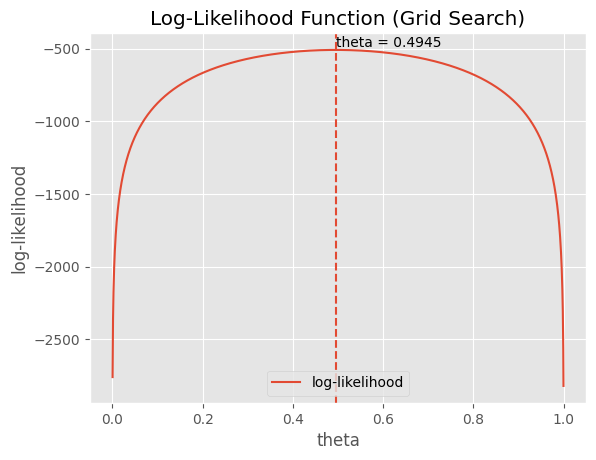

In [ ]:
# theta（端点回避）
list_theta = np.arange(0.0005, 1, 0.0005)

def log_likelihood(theta, df):
    return df["female"].sum() * np.log(theta) + df["male"].sum() * np.log(1 - theta)

# 対数尤度を計算
ll_values = [log_likelihood(theta, df) for theta in list_theta]

# グリッド上の最大値
idx_max = np.argmax(ll_values)
theta_max = list_theta[idx_max]
ll_max = ll_values[idx_max]

# プロット
plt.style.use('ggplot')
plt.plot(list_theta, ll_values, label="log-likelihood")

# 最大点の縦線（点線）
plt.axvline(theta_max, linestyle='--')

# 注釈
plt.text(theta_max, ll_max,
         f"theta = {theta_max:.4f}",
         ha='left', va='bottom')

plt.xlabel("theta")
plt.ylabel("log-likelihood")
plt.title("Log-Likelihood Function (Grid Search)")
plt.legend()
plt.savefig("test.png")
plt.show()